**Compute Distances in Different Dimensions**

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist

def analyze_distances(n_points=1000, dim=2):
    points = np.random.rand(n_points, dim)
    distances = pdist(points, metric='euclidean')

    min_d = np.min(distances)
    max_d = np.max(distances)
    ratio = min_d / max_d

    return min_d, max_d, ratio

# 2D
min2, max2, ratio2 = analyze_distances(dim=2)
print("2D:")
print("Min:", min2, "Max:", max2, "Ratio:", ratio2)

# 10D
min10, max10, ratio10 = analyze_distances(dim=10)
print("\n10D:")
print("Min:", min10, "Max:", max10, "Ratio:", ratio10)

2D:
Min: 0.0010792416095232245 Max: 1.38266765491561 Ratio: 0.0007805502686682109

10D:
Min: 0.21042339016709305 Max: 2.314926797629632 Ratio: 0.09089850719364256


Explained variance ratio: [0.92461872 0.05306648]


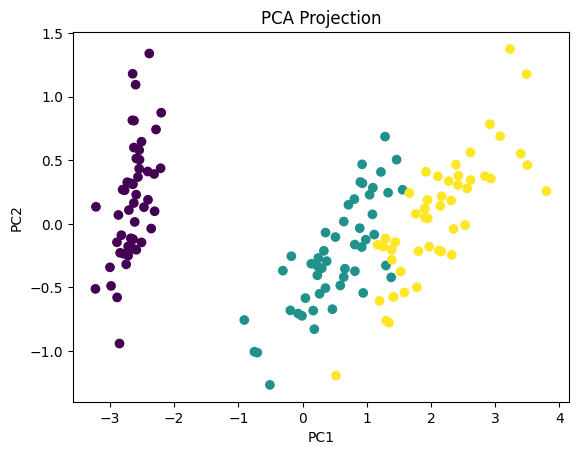

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load dataset
X, y = load_iris(return_X_y=True)

# Apply PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

# Model
encoding_dim = 32

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation="relu")(input_img)
decoded = layers.Dense(784, activation="sigmoid")(encoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0705 - val_loss: 0.0421
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0361 - val_loss: 0.0304
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0263 - val_loss: 0.0222
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0204 - val_loss: 0.0181
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0171 - val_loss: 0.0155
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0150 - val_loss: 0.0137
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0135 - val_loss: 0.0125
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0125 - val_loss: 0.0117
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0118 - val_loss: 0.0111
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0113 - val_loss: 0.0108
